# Progetto Python "Analisi dei disastri aerei dal 1919 al 2023"
Il progetto richiede di svolgere un'accurata analisi di tutti gli incidenti aerei che si sono verificati dal 1919 al 2023, individuando trend, pattern e velivoli più pericolosi.

Obbiettivo dell'anaisi:
*  Analizzare l'andamento dei disastri aerei nel tempo valutare l'impatto dell'attentato dell'11/09/2001.
*  Identificare le nazioni con il maggior numero di incidenti e vittime.
*  Valutare la sicurezza delle compagnie aeree, distinguendo quelle con meno incidenti.
*  Evidenziare le compagnie con il maggior numero di incidenti e vittime.
*  Individuare i velivoli che hanno causato più vittime, sia in termini totali sia in media per incidente.
*  Analizzare in quali giorni della settimana si sono verificati più incidenti e più vittime.

Step 1: Creazione, Analisi e Pulizia Dataframe
*  Importazione modulo Pandas.
*  Importazione Pyplot dal modulo Matplotlib.
*  Creazione del dataframe a partire dal CSV.
*  Duplicazione del dataframe e analisi dati: verifica valori mancanti, duplicati e uniformità dei dati
*  Pulizia e modifica dei dati utilizzando le funzioni di pandas.

Step 2:Creazione Insight e grafici
*  Calcolo Top 10 numero di incidenti per nazione (Bar Chart).
*  Calcolo Top 10 per nazione con il maggior numero di vittime (Bar Chart).
*  Individuazione Compagnie aeree più sicure (Bar Chart)
*  Analisi dell'andamento degli incidenti per anno dal 1919 al 2023, con evidenziazione del trend dopo l'11/09/2001 (Line Chart).
*  Individuazione dei velivoli che hanno causato il maggior numero di vittime (Bar Chart).
*  Verifica degli apparecchi più sicuri, in base agli incidenti causati (Bar Chart)
*  Individuazione velivoli più pericolosi in base alla media di morti per incidente(Bar Chart).
*  Analisi degli incidenti per giorno della settimana, sia in numero totale sia in media (Bar Chart)




In [ ]:
# Importo le librerie necessarie per analizzare e lavorare sul file
import pandas as pd
from matplotlib import pyplot as plt


In [ ]:
# Importo il csv tramite il modulo read_csv e creo il nuovo dataframe
df = pd.read_csv("/content/drive/MyDrive/Progetto disastri aerei/aviation-accidents.csv")

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown
...,...,...,...,...,...,...,...,...,...
23962,11-MAY-2023,Hawker 900XP,PK-LRU,Angkasa Super Services,0,Maleo Airport (MOH),Indonesia,A2,2023
23963,11-MAY-2023,Cessna 208B Grand Caravan,PK-NGA,Nasional Global Aviasi,0,Fentheik Airstrip,Indonesia,A2,2023
23964,12-MAY-2023,Cessna 208B Grand Caravan,5X-RBR,Bar Aviation,0,Kampala-Kajjansi...,Uganda,A1,2023
23965,14-MAY-2023,Boeing 747-4R7F,LX-OCV,Cargolux,0,Luxembourg-Finde...,Luxembourg,A2,2023


In [ ]:
def remove_columns(df, thresold = 0.2):
  """
  Creo una funzione per verificare i valori mancanti all'interno di un dataframe e, secondo la percentuale scelta eliminare quelle che superano la soglia
  - df è il dataframe da pulire
  - di defaulti il Thresold è tarato al 20%
  """
  total_values = len(df) # Calcolo il totale dei valori del DF
  missing_values = df.isnull().sum() # Verifico il numero di valori mancanti per il DF
  deleted_columns = 0 # Creo un contatore per le colonne che verranno cancellate

  for column in df.columns: # Avvio di un ciclo sulle colonne del DF
    missing_ratio = missing_values[column]/total_values # Creo una variabile che conteggia la percentuale di valori mancanti per ogni colonna
    if missing_ratio > thresold: # Se la percentuale di valori mancanti supera il thresold...
      df = df.drop(column, axis = 1) # ...elimino la colonna
      print(f"Colonna {column} eliminata.") # Stampo il nome della colonna cancellata e la percentuale di valori mancanti
      print(f"Percentuale valori mancanti: {missing_ratio:.2f}")
      deleted_columns += 1 # Aggiorno il contatore delle colonne cancellate
  if deleted_columns == 0: # Se non viene eliminata nessuna colonna
    print("Nessuna colonna eliminata") # Stampo il messaggio

  return df # Ritorno il DF pulito.

# Alla luce del fatto che verranno creati diversi grafici opto per la creazione di alcune funzioni che mi permettano di inserire i dati senza ripetere righe di codice
# Grafico a Barre verticali
def bar_chart(dati, title, xlabel, ylabel, color = "skyblue", rotation = 45):
    plt.figure (figsize = (12, 6)) # Imposto la grandezza standard del grafico
    plt.bar(dati.index, dati.values, color = color) # Richiamo i valori sulle colonne e inserisco il colore standard
    plt.title(title) # Do il titolo al grafico
    plt.xlabel(xlabel) # All'asse delle x
    plt.ylabel(ylabel) # A quello delle y
    plt.xticks(rotation = rotation) # Inserisco una rotazione di 45 gradi per i titoli dell'asse delle x
    plt.show() # mostro il grafico

# Grafico a Barre orizzontali
def barh_chart(dati, title, xlabel, ylabel, color = "skyblue", rotation = 45):
    plt.figure (figsize = (12, 6))
    plt.barh(dati.index, dati.values, color = color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation = rotation)
    plt.show()

# Grafico a linee
def line_chart(dati, title, xlabel, ylabel, color = "skyblue", rotation = 45):
    plt.figure (figsize = (12, 6))
    plt.plot(dati.index, dati.values, color = color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation = rotation)
    plt.annotate("Evoluzione incidenti dall'11/09/2001", xy=(2001, 225), xytext = (2001,500), arrowprops=dict(facecolor = "black"))
    plt.show()





In [ ]:
### Prima fase pulizia DataFrame ###

# Creo una copia del DataFrame per non lavorare direttamente sull'originale
df_cleaned = df.copy()

# Tramite la funzione remove_columns verifico la solidità dei dati
df_cleaned = remove_columns(df_cleaned)

# N.B. Nessuna colonna è stata elminata perchè la percentuale di dati mancanti è inferiore al thresold

### Seconda fase pulizia DataFrame ###

# Sono presenti molte date non popolate o con formato differente.
# Utilizzo il metodo pandas "to_datetime" per modificare i campi in data
# In caso di dati mancanti o errori verrà inserito NaT

# Imposto il formato in d/m/Y
df_cleaned["date"] = pd.to_datetime(df_cleaned["date"], errors = "coerce", dayfirst=True)

# Modifico la colonna year trasformando tutti i dati nel formato YYYY e inserendo NA per i campi mancanti
df_cleaned["year"] = (pd.to_numeric(df_cleaned["year"], errors="coerce"))

# Nella colonna country sono presenti dati sconosciuti e con simbolo "?", utilizzo replace per sostituirli con "NA"
df_cleaned["country"] = df_cleaned["country"].replace(["Unknown country","","?"], pd.NA)

# Pulisco la colonna fatalities trasfrormando tutti i dati in numeri
df_cleaned["fatalities"] = pd.to_numeric(df_cleaned["fatalities"], errors="coerce")

# Modifico il tipo di dato per fatalities da float a int
df_cleaned["fatalities"] = df_cleaned["fatalities"].astype("Int64") # Ho dovuto modificare il tiopo di dato in Int64 perchè int e int64 restituivano errore

df_cleaned["year"] = df_cleaned["year"].astype("Int64")

Nessuna colonna eliminata


/tmp/ipykernel_182/4163290370.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned["date"] = pd.to_datetime(df_cleaned["date"], errors = "coerce", dayfirst=True)


# Numero incidenti per nazione

Top Ten incidenti per nazione: 
country
USA         4377
Russia      1422
U.K.         837
Canada       826
India        700
Brazil       609
France       550
Germany      516
China        514
Colombia     457
Name: count, dtype: int64


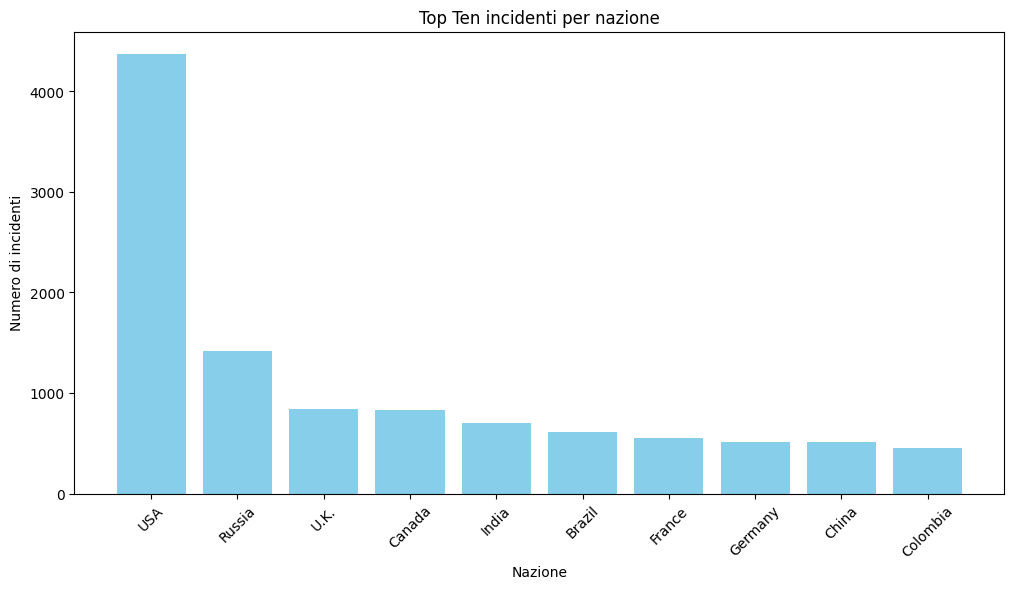

In [ ]:
# Voglio evidenziare le prime 10 nazioni per numero di incidenti, utilizzando la colonna country, visualizzando le prime 10 occorrenze in ordine decrescente
df_country_top10 = df_cleaned["country"].value_counts().head(10) # Utilizzo il metodo value_counts() per conteggiare i valori, escludendo gli NA
# Stampo a video la classifica
print("Top Ten incidenti per nazione: ")
print(df_country_top10)
# Creo il grafico
bar_chart(df_country_top10, "Top Ten incidenti per nazione", "Nazione", "Numero di incidenti")



### Dall'analisi dei dati si evidenzia come gli Stati uniti dominano nettamente la classifica degli incidenti aerei nel corso degli anni. Questo dato però è sicuramente influenzato dall'elevato volume di traffico aereo rispetto alle altre nazioni.

# Numero di vittime per nazione

Numero di vittime per nazione (Top10)
country
USA               14431
Russia             9426
Colombia           3268
France             3244
India              3136
Brazil             3084
Atlantic Ocean     2900
Indonesia          2766
Spain              2756
China              2630
Name: fatalities, dtype: Int64


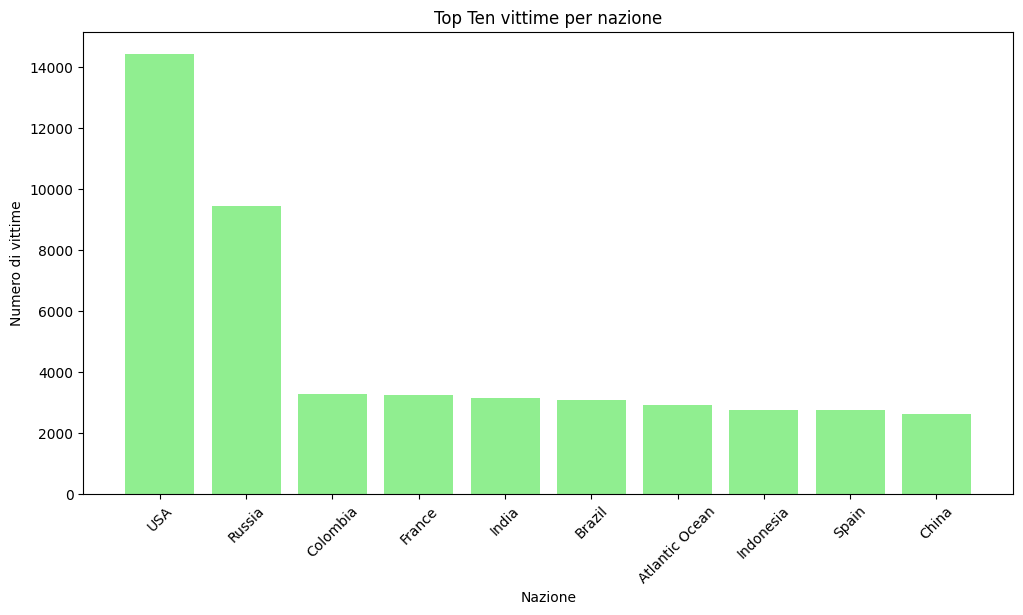

In [ ]:
# Calcoliamo, per nazione il numero totale di vittime ("fatalities"). Il dato verrà limitato alle prime 10 in ordine decrescente.
df_fatalities_top10 = df_cleaned.groupby("country")["fatalities"].sum().sort_values(ascending = False).head(10)
print("Numero di vittime per nazione (Top10)")
print(df_fatalities_top10)
bar_chart(df_fatalities_top10, "Top Ten vittime per nazione", "Nazione", "Numero di vittime", "lightgreen")

### Non tutti gli incidenti hanno lo stesso impatto in termini di vittime: sebbene per gli Stati Uniti e la Russia non cambi la posizione in classifica, dal terzo posto rileviamo un rapporto vittime/incidente che viene totalmente stravolto. Ad Esempio, gli U.K, dal secondo posto per numeri incidenti non compaiono più in top ten, mentre la Colombia, da decima come numero totale di incidenti è terza per vittime.

# Compagnie aeree:
## Top 10 più pericolose
## Top 10 meno pericolose

Top 10 vettori più pericolosi
operator
Air-India                  32.12
Aeroflot, International     29.1
China Airlines             26.08
JAL                        21.57
THY                        19.61
Saudi Arabian              17.92
EgyptAir                   17.87
Swissair                   16.96
Iran AF                    16.92
Aeroflot, Uzbekistan       15.44
dtype: Float64
Top 10 vettori meno pericolosi
operator
Southwest Airlines    0.04
ZUA                   0.11
Unknown               0.75
Private               0.89
FAA                    0.9
private               0.91
Aeroflot, MAGON        1.5
USAAF                 1.74
Air Union             1.85
Delta Air Lines       1.88
dtype: Float64


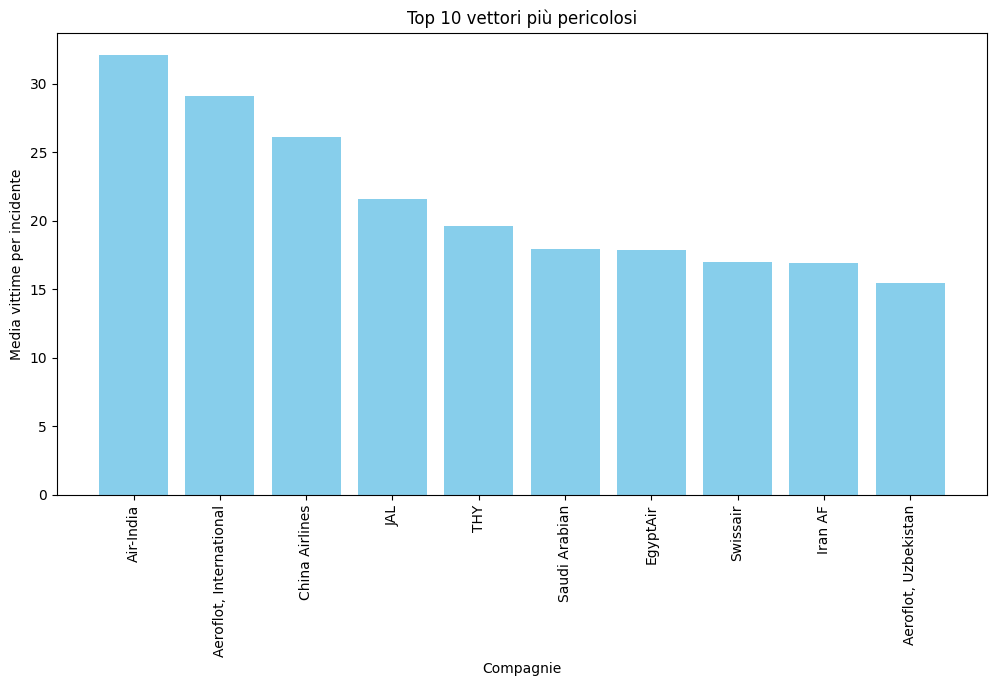

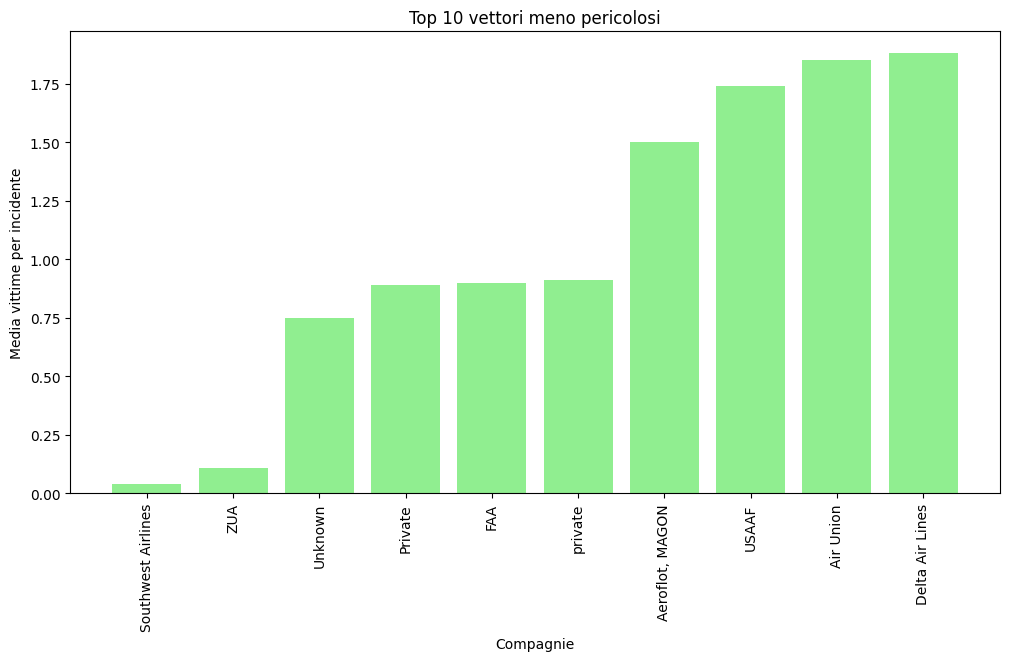

In [ ]:
# Calcoliamo il numero di incidenti per ogni compagnia aerea
incidenti_per_compagnia = df_cleaned.groupby("operator").size()
# Individuato le compagnie con almeno 20 incidenti registrati (creiamo una series)
operatori_selezionati = incidenti_per_compagnia[incidenti_per_compagnia>=20].index
# verifichiamo quali operatori sono presenti nella series precedentemente creata
df_operatori_filtrati = df_cleaned[df_cleaned["operator"].isin(operatori_selezionati)]
# Calcoliamo il numero di incidenti per gli operatori filtrati
incidenti_filtrati = df_operatori_filtrati.groupby("operator").size()
# Conteggioamo le vittime per ogni operatore
morti_per_Compagnia = df_operatori_filtrati.groupby("operator")["fatalities"].sum()
# Calcoliamo la media di vittime per incidente di ogni compagnia con almeno 20 incidenti e selezioniamo le 10 con più ittime e le 10 con meno vittime
media_per_compagnia = round(morti_per_Compagnia/incidenti_filtrati, 2)
compagnie_più_pericolose = media_per_compagnia.sort_values(ascending=False).head(10)
compagnie_meno_pericolose = media_per_compagnia.sort_values().head(10)
print("Top 10 vettori più pericolosi")
print(compagnie_più_pericolose)
print("Top 10 vettori meno pericolosi")
print(compagnie_meno_pericolose)

bar_chart(compagnie_più_pericolose, "Top 10 vettori più pericolosi", "Compagnie", "Media vittime per incidente", rotation = 90)
bar_chart(compagnie_meno_pericolose, "Top 10 vettori meno pericolosi", "Compagnie", "Media vittime per incidente",color = "lightgreen", rotation = 90)

### Confrontando le compagnie più pericolose con quelle più sicure, emerge un netto squilibrio tra le compagnie del continente asiatico e il resto del mondo. Le prime tre compagnie con la media vittime per incidente più elevata (considerando un minimo di 20 incidenti) provengono dall'India, dalla Russia (Aeroflot) e dalla Cina. Per contro, tra le compagnie più sicure figura Delta Airlines, una delle principali compagnie americane e mondiali

# Analisi andamento incidenti (1919 - 2023)

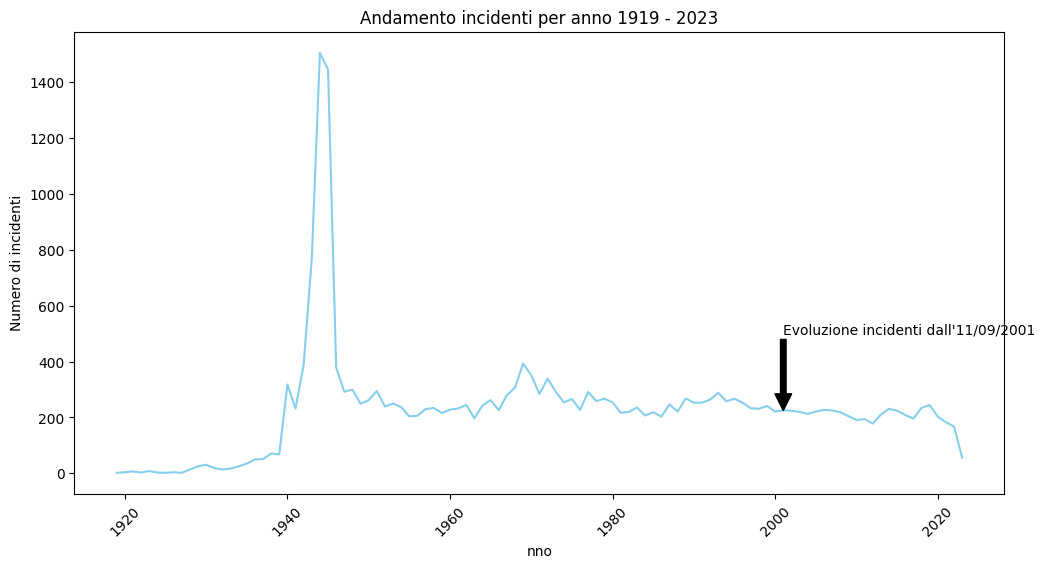

In [ ]:
# Rileviamo il numero di incidenti per ogni anno
df_incidents_year = df_cleaned.groupby("year").size()
line_chart(df_incidents_year, "Andamento incidenti per anno 1919 - 2023", "nno", "Numero di incidenti")


### A partire dal 1919 (sedici anni dopo il primo volo dei fratelli Wright) il numero di incidenti è andato in crescita, toccando il picco tra gli anni a cavallo della seconda guerra mondiale. In seguito il numero di eventi è stato stabile, con un leggero picco intorno agli anni '70. In relazione all'evento traumatico dell'11/09/2001, l'attentato alle torri gemelle di New York, assistiamo ad un leggero, ma continuo calo fino al 2023

# Velivoli che hanno causato più vittime

Top 10 veicoli che hanno causato più vittime: 
type
Douglas C-47A (DC-3)        5689
Douglas C-47 (DC-3)         2619
Douglas C-47B (DC-3)        1994
Tupolev Tu-154M             1395
Ilyushin Il-18V             1356
DC-9-32                     1207
Lockheed C-130H Hercules    1192
Antonov An-26               1163
Junkers Ju-52/3m            1114
Douglas DC-6B               1040
Name: fatalities, dtype: Int64


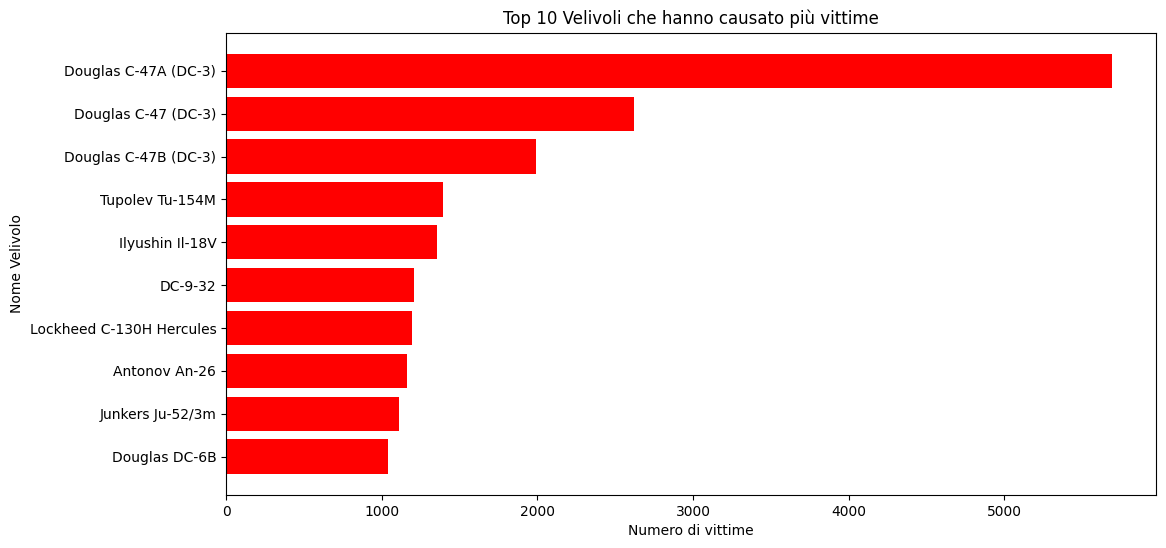

In [ ]:
# Individuiamo ed evidenziamo i primi dieci tipi di velivolo che hanno causato più morti negli incidenti documentati
df_type_most_fatalities = df_cleaned.groupby("type")["fatalities"].sum().sort_values(ascending=False).head(10)
print("Top 10 veicoli che hanno causato più vittime: ")
print(df_type_most_fatalities)
barh_chart(df_ordinato,"Top 10 Velivoli che hanno causato più vittime", "Numero di vittime", "Nome Velivolo", color = "red", rotation = 0)


### Nella classifica dei velivoli più "pericolosi" troneggia il Douglas C-47A (DC-3) con più del doppio delle vittime rispetto al secondo in classifica. Questo dato però va interpretato con cautela, infatti l'aereo in questione era uno dei più diffusi al mondo, quindi l'alto numero di vittime potrebbe riflettere la sua diffusione più che una pericolosità intrinseca.

#Velivoli:
### Top 10 più pericolosi
### Top 10 meno pericolosi

Top 10 velivoli più pericolosi
type
Tupolev Tu-154M                 41.03
Tupolev Tu-104B                  30.1
Tupolev Tu-154B-2                29.2
Ilyushin Il-18D                 28.43
Ilyushin Il-18V                 25.58
Tupolev Tu-134A                  21.2
DC-10-30                        20.52
DC-9-82 (MD-82)                 20.21
Airbus A321-231                  18.8
Lockheed L-049 Constellation    18.78
dtype: Float64
Top 10 velivoli più pericolosi
type
Airbus A320-214                   0.0
DC-8                             0.03
Boeing 737                       0.04
DC-9                             0.06
Boeing 727                       0.07
Boeing 707                       0.08
Boeing 737-200                   0.26
Cessna 208B Super Cargomaster    0.46
Antonov An-2T                    0.58
BN-2A-8 Islander                 0.65
dtype: Float64


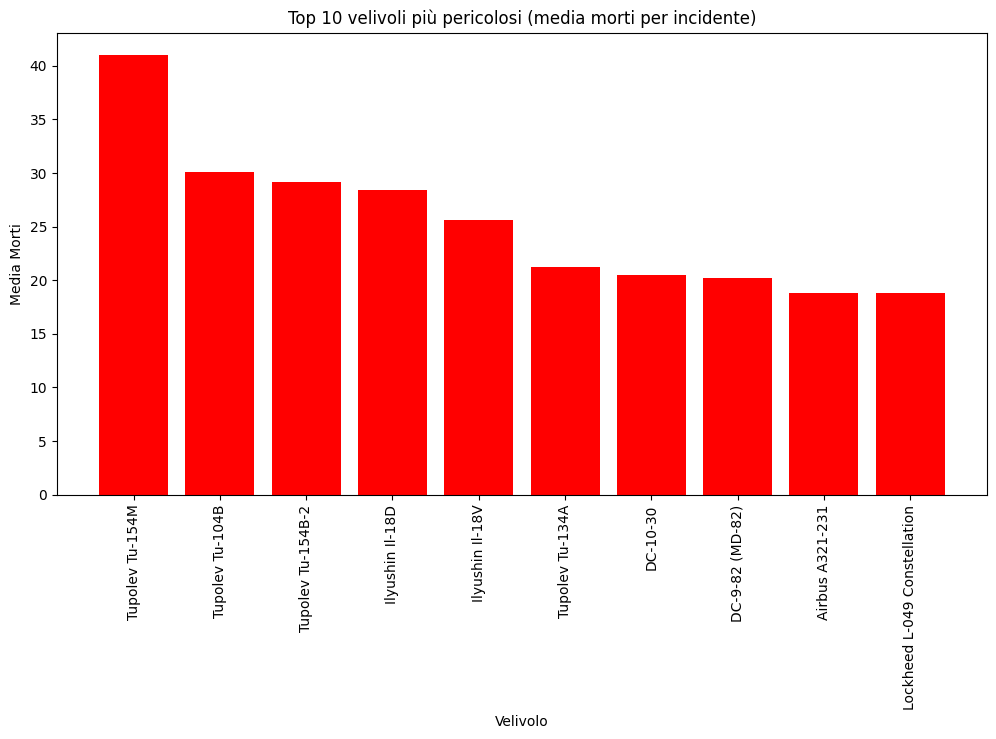

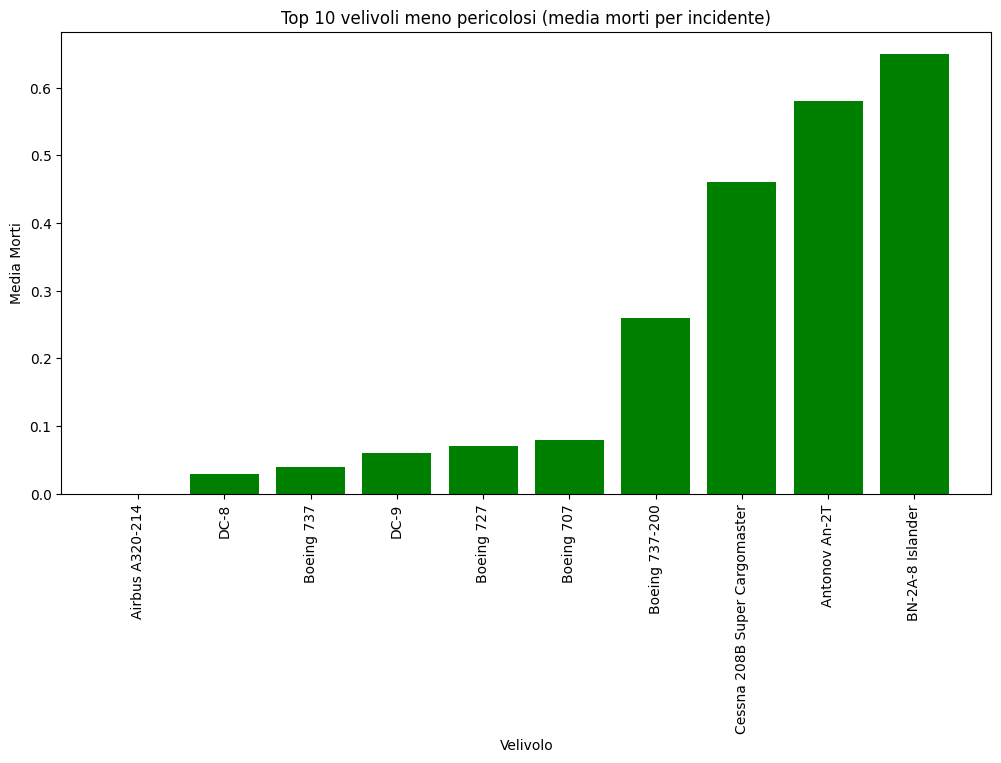

In [ ]:
# Per individuare i velivoli più "Pericolosi", cioè i velivoli che hanno causato, in media più vittime rispetto agli incidenti
# Abbiamo calcolato il numero di incidenti per velivolo "incidenti_per_velivolo"
incidenti_per_velivolo = df_cleaned.groupby("type").size()
# Abbiamo individuato gli apparecchi con almeno 20 incidenti registrati
velivoli_selezionati = incidenti_per_velivolo[incidenti_per_velivolo>=20].index
velivoli_filtrati=df_cleaned[df_cleaned["type"].isin(velivoli_selezionati)]
incidenti_filtrati = velivoli_filtrati.groupby("type").size()

# Numero di morti per velivolo
morti_per_velivolo = velivoli_filtrati.groupby("type")["fatalities"].sum()

# Calcolato la media di morti per velivolo (morti/incidenti)
media_apparecchio = round(morti_per_velivolo/incidenti_filtrati, 2)
most_dangerous = media_apparecchio.sort_values(ascending=False).head(10)
less_dangerous = media_apparecchio.sort_values().head(10)

print("Top 10 velivoli più pericolosi:")
print(most_dangerous)
print("Top 10 velivoli meno pericolosi:")
print(less_dangerous)

bar_chart(most_dangerous, "Top 10 velivoli più pericolosi (media morti per incidente)", "Velivolo", "Media Morti", color = "red", rotation = 90)
bar_chart(less_dangerous, "Top 10 velivoli meno pericolosi (media morti per incidente)", "Velivolo", "Media Morti", color = "green", rotation = 90)


### Il Tupolev, di fabbricazione russa, è l'aereo più pericoloso al mondo tra quelli con almeno 20 incidenti registrati: le diverse versioni dello stesso modello occupano le prime tre posizioni della classifica. Sul fronte opposto, Airbus, Douglas e Boeing dominano la classifica degli apparecchi più sicuri.

# Numero incidenti per giorno della settimana

Incidenti per giorno della settimana
giorno_settimana
Monday       3317
Tuesday      3444
Wednesday    3491
Thursday     3516
Friday       3701
Saturday     3186
Sunday       2753
dtype: int64


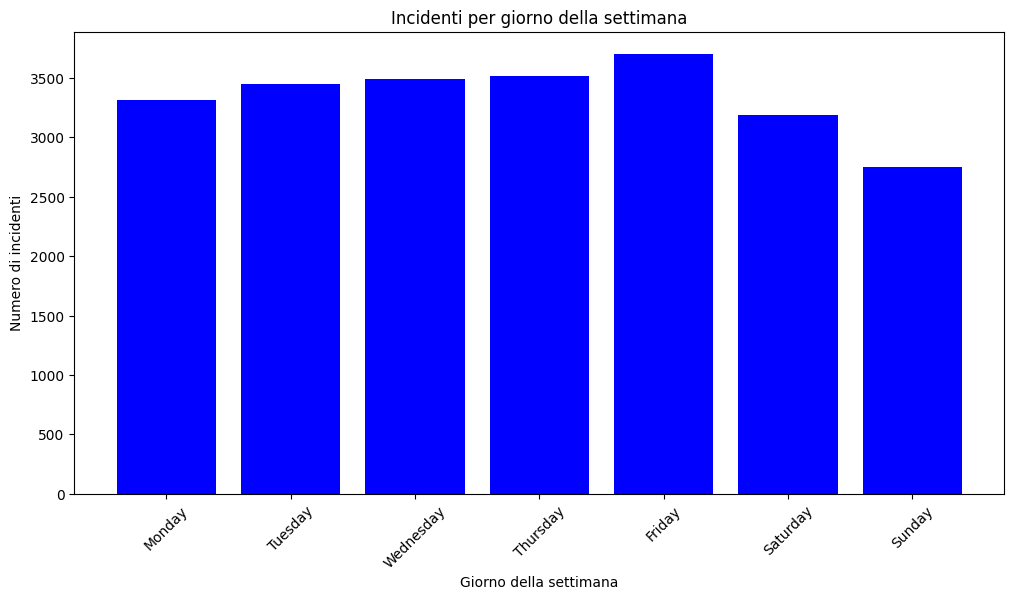

In [ ]:
# Per individuare in quale giorno della settimana si verificano più incidenti, abbiamo creato una serie sostituendo alla data il nome del giorno
df_cleaned["giorno_settimana"] = df_cleaned["date"].dt.day_name()
# Abbiamo calcolato il totale degli incidenti per giorno specifico
eventi_per_giorno = df_cleaned.groupby("giorno_settimana").size()
# Creato un ordine dei giorni, per avere l'andamento della settimana corretto.
ordine=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# Ordinato il tutto secondo l'ordine prestabilito
eventi_ordinati=eventi_per_giorno.reindex(ordine)
print("Incidenti per giorno della settimana")
print(eventi_ordinati)
bar_chart(eventi_ordinati, "Incidenti per giorno della settimana", "Giorno della settimana", "Numero di incidenti", color = "blue")


### Non viaggiate di venerdì! Da questa analisi il giorno in cui si rileva il più alto numero di incidenti è proprio quello, anche se la differenza con gli altri giorni della settimana è minima, solo la domenica sembra che si possa viaggiare con un po' di sicurezza in più. E'comunque opportuno considerare che la differenza tra i giorni è contenuta e potrebbe riflettere semplicemente una maggiore intensita del traffico aereo nei giorni feriali rispetto al weekend

# Media incidenti per giorno della settimana

        date  eventi    weekday
0 1919-08-02       1   Saturday
1 1919-08-11       1     Monday
2 1920-02-23       1     Monday
3 1920-02-25       1  Wednesday
4 1920-06-30       1  Wednesday
Media incidenti per giorno della settimana: 
weekday
Monday       1.56
Tuesday      1.60
Wednesday    1.58
Thursday     1.58
Friday       1.64
Saturday     1.55
Sunday       1.53
Name: eventi, dtype: float64
Il giorno peggiore nella storia: 
          date  eventi weekday
432 1940-05-10     171  Friday


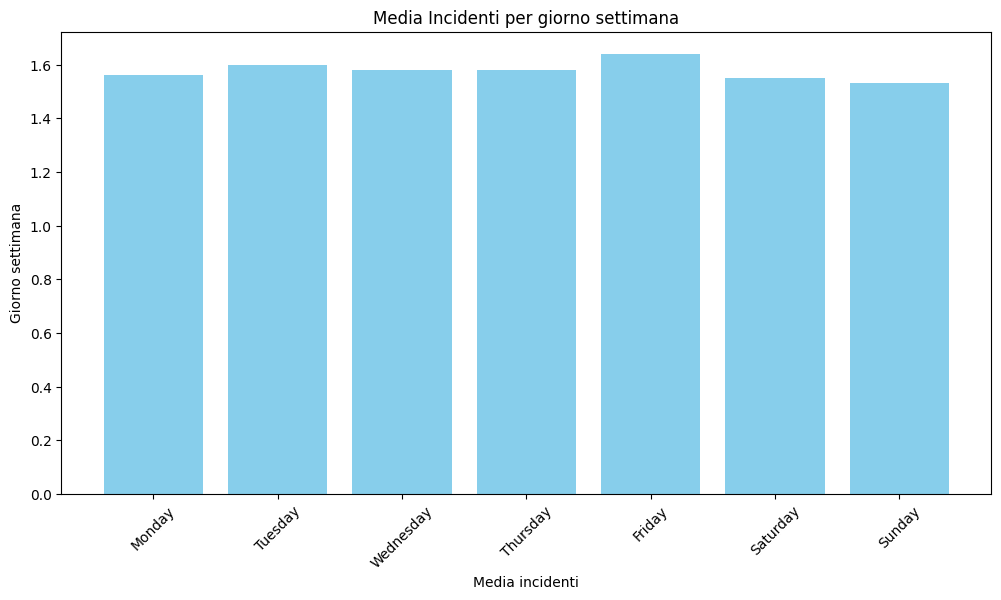

In [ ]:
# Per capire in media quanti incidenti si verificano per giorno della settimana abbiamo calcolato
# Contiamo quanti incidenti ci  sono stati per ogni singola data e creiamo un nuovo dataframe con la nuova colonna "eventi"
eventi_per_data = df_cleaned.groupby("date").size().reset_index(name="eventi")
# inseriamo una nuova colonna chiamata "weekday" assegnando il nome della settimana alla data
eventi_per_data["weekday"] = pd.to_datetime(eventi_per_data["date"]).dt.day_name()
# Calcoliamo per ogni giorno la media di eventi
media_eventi = eventi_per_data.groupby("weekday")["eventi"].mean()
# Ordiniamo gli eventi utilizzando la lista ordine precedentemente creata e calcoliamo la media arrotondando per due i decimali
eventi_ordinati_media = round(media_eventi.reindex(ordine),2)
#Stampiamo le prime cinque righe del nuovo dataframe creato per verifica
print(eventi_per_data.head(5))
print("Media incidenti per giorno della settimana: ")
print(eventi_ordinati_media)
print("Il giorno peggiore nella storia (Battaglia di Sedan)")
print(eventi_per_data.sort_values("eventi", ascending=False).head(1)) # Il giorno nella storia con più incidenti
bar_chart(eventi_ordinati_media, "Media Incidenti per giorno settimana", "Media incidenti", "Giorno settimana", color = "skyblue")


### La media incidenti per giorno conferma il dato assoluto: il venerdì è il giorno più critico in entrambe le analisi, suggerendo che la maggiore frequenza non è semplicemente dovuta a un volume di voli più alto, ma potrebbe riflettere altri fattori come la stanchezza dei piloti accumulata a fine settimana lavorativa.
### Per curiosità abbiamo cercato di individuare il giorno in cui si sono verificati più incidenti nell'arco di tempo esaminato, si tratta del 10 maggio 1940 (Battaglia di Sedan), durante la seconda guerra mondiale, con 171 incidenti registrati.

# Commento finale
### L'analisi dei quasi 25000 incidenti aerei registrati tra il 1919 e il 2023 restituisce un quadro articolato della sicurezza mondiale. Se da un lato il numero assoluto di incidenti vede gli Stati Uniti in testa con più di 4000 eventi e quasi 15000 vittime, questo dato va contestualizzato con il volume di traffico aereo storicamente più elevato del mondo. Più significativo è il trend temporale: a partire dall'11 settembre 2001 si registra un calo costante degli incidenti, a testimonianza di come eventi traumatici possano accelerare l'adozione di misure di sicurezza più stringenti. Sul fronte velivoli, il Tupolev si conferma il più pericoloso per media vittime incidente, mentre le grandi compagnite occidentali (come Airbus e Boeing) dominano la classifica oppposta. Lo stesso squilibrio geografico si rilfette tra le compagnie aeree, con i vettori asiatici che mostrano una media vittime più elevato rispetto a quelli occidentali.